In [2]:
import pandas as pd
import numpy as np

## 1. Load the Dataset

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [4]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity 


# PE => produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
X = df.drop("PE", axis =1)
y = df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

### 1.2. Scaling and Train test split

In [19]:
# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 41
)

In [20]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Converting data into Tensors

In [21]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

# these are stored in the machine RAM

## 3. Tensor Dataset and DataLoader

In [22]:
from torch.utils.data import TensorDataset, DataLoader

# Creating tensor Dataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# first parameter = input dataset, second = output dataset
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [23]:
# creating dataloader

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
# shuffle = True ensures data is shuffled before being divided into batches.
test_loader = DataLoader(test_dataset, batch_size = 32)

## 4. Defining the ANN model

### Deep Learning

In [28]:
# Defining the ANN Model

class ANN(nn.Module): # we can name the class anything
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden
            nn.Linear(X_train.shape[1], 6), # 1st param = input features, 2nd = output features
            nn.ReLU(),
    
            # 2nd hidden
            nn.Linear(6,6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1)
        )

    # forward propagation
    def forward(self, x):
        return self.model(x)

In [29]:
# Build the model

import torch.optim as optim  # optimizer import

model = ANN()

# customize loss, optimizer

criterion = nn.MSELoss() # mean squared error as this is regression model
optimizer = optim.Adam(model.parameters())

## 5. Training the Model

In [30]:

train_losses = []
val_losses = []

best_val_loss = float("inf") # the best loss value for the model initialized to infinity.

epochs = 100

for epoch in range(epochs):
    model.train()  # training mode
    running_loss = 0.0 # total training loss for one epoch

    # Training 
    
    for xb, yb in train_loader:  
        # xb = features of one batch
        # yb = labels of one batch
        optimizer.zero_grad() # changes previously calculated gradients to zero, so that
                              # fresh gradients are calculated.
        
        outputs = model(xb) # forward propagation --- final layer predicted output
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # backward prop.. compute gradients
        optimizer.step() # parameters update

        running_loss += loss.item() # loss is a tensor -> convert to python float value

    epoch_train_loss = running_loss/ len(train_loader) # avg. running loss for 1 epoch
    train_losses.append(epoch_train_loss) # appending loss for 1 epoch in the array

    # Validation
    model.eval() # evaluation mode
    # it is important to write this line to change the mode of the model to evaluation mode.
    running_val_loss = 0.0

    with torch.no_grad(): # don't compute any gradients, otherwise pytorch automatically
                          # computes the gradients. so it saves memory and speed.
        for xb, yb in test_loader :
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss
    
            # no backward propagation as we are validating the testing, so we don't want 
            # to adjust the weights and biases.

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")


    # comparing the best loss value with the current epoch loss value.
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")  # .pt or .pth extension for pytorch file.
        # the state_dict() stores the values of the parameters of the epoch.

epoch 1/100 ==> train loss = 205990.46666666667 & val loss = 203282.046875
epoch 2/100 ==> train loss = 197021.32591145832 & val loss = 185414.828125
epoch 3/100 ==> train loss = 163542.360546875 & val loss = 134400.96875
epoch 4/100 ==> train loss = 102324.24140625 & val loss = 70707.65625
epoch 5/100 ==> train loss = 48416.22994791667 & val loss = 30407.580078125
epoch 6/100 ==> train loss = 21313.44723103841 & val loss = 16695.98828125
epoch 7/100 ==> train loss = 13972.248223876953 & val loss = 12794.4150390625
epoch 8/100 ==> train loss = 10805.54403483073 & val loss = 9786.505859375
epoch 9/100 ==> train loss = 8062.567521158854 & val loss = 6996.28955078125
epoch 10/100 ==> train loss = 5759.035689290365 & val loss = 5051.95263671875
epoch 11/100 ==> train loss = 4253.146477254232 & val loss = 3692.8671875
epoch 12/100 ==> train loss = 3131.6225524902343 & val loss = 2674.2587890625
epoch 13/100 ==> train loss = 2278.5680997212726 & val loss = 1916.11181640625
epoch 14/100 ==> t

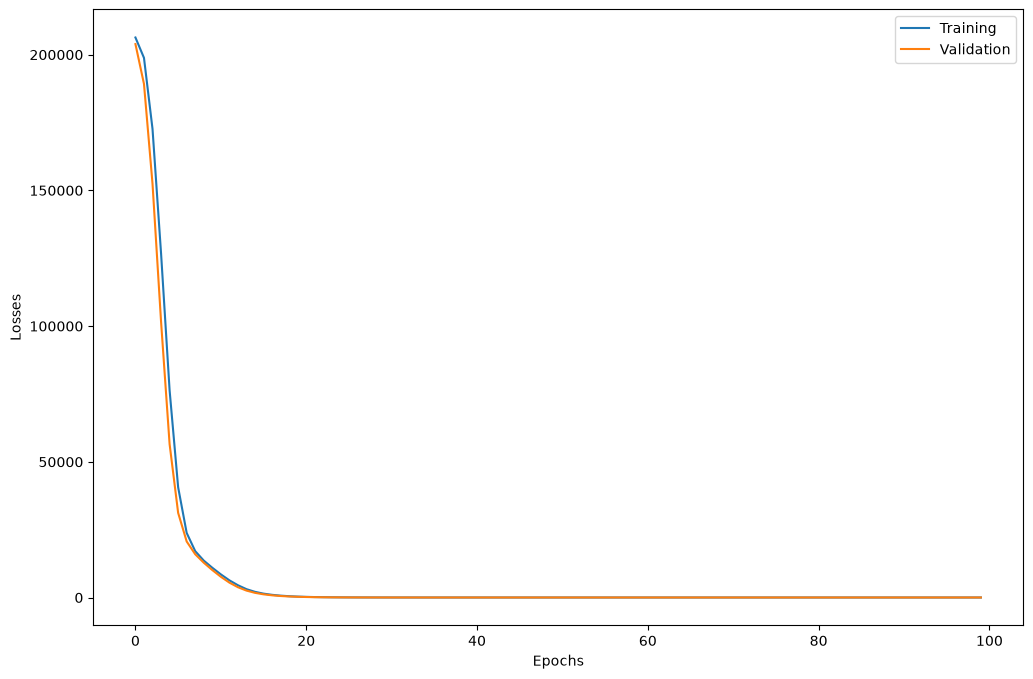

In [27]:
# plotting the loss

import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss" : val_losses
}
)

plt.figure(figsize = (12,8))
plt.plot(loss_df["Training Loss"], label = "Training")
plt.plot(loss_df["Validation Loss"], label = "Validation")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [31]:
# Loading the best model
# And adding the parameters to the model
# after running this code, the model will come to the state where the validation loss 
# is minimum, not at the 100th epoch.
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

## 6. Evaluation

In [37]:
# We check the loss and print it.

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)


print(f"Training MSE : {train_mse_loss.item()} and Testing MSE : {test_mse_loss.item()}")
# .item() because we have to convert the tensor value to float value, for that we use .item .

Training MSE : 20.453996658325195 and Testing MSE : 20.19866943359375


In [38]:
from sklearn.metrics import r2_score

print("r2 score : ", r2_score(y_test, test_preds))

r2 score :  0.9275819525528002


### Comparing the values in tabular form

In [39]:
predicted_df = pd.DataFrame(
    test_preds.numpy(), columns = ["Predicted Values"]
)
actual_df = pd.DataFrame(
    y_test.values, columns=["Actual Values"]
)

pd.concat([predicted_df, actual_df], axis = 1)

,Predicted Values,Actual Values
0,450.476013,449.03
1,483.610779,485.24
2,434.025116,435.77
3,469.943970,466.05
4,447.410339,447.43
...,...,...
1909,474.262512,473.56
1910,484.872406,486.06
1911,431.003662,436.13
1912,429.846375,432.62
